<a href="https://colab.research.google.com/github/MYunan17/PCVK-Genap-25-26/blob/main/Week5_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

E-1 PERCOBAAN HISTOGRAM

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

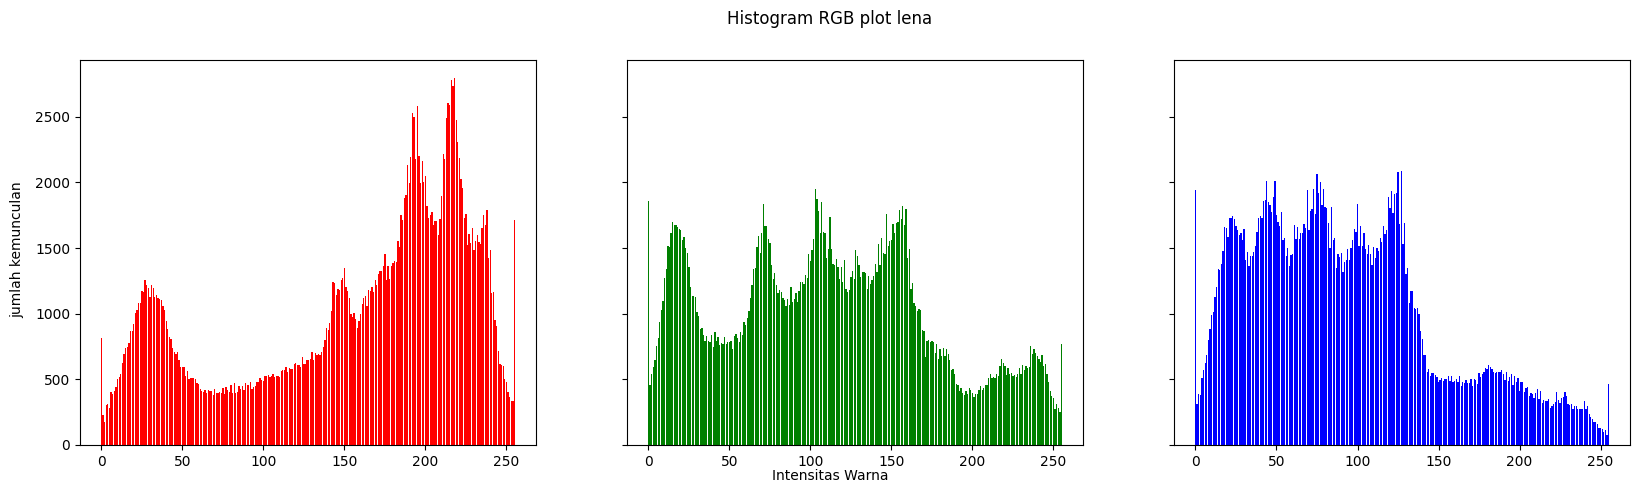

In [10]:
img = cv.imread('/content/drive/MyDrive/lena.jpeg')

img = cv.cvtColor(img,cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256


for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

name = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot lena')
fig.text(0.09, 0.5, 'jumlah kemunculan',va='center',rotation='vertical')
fig.text(0.5,0.04,'Intensitas Warna', ha = 'center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')

<BarContainer object of 256 artists>

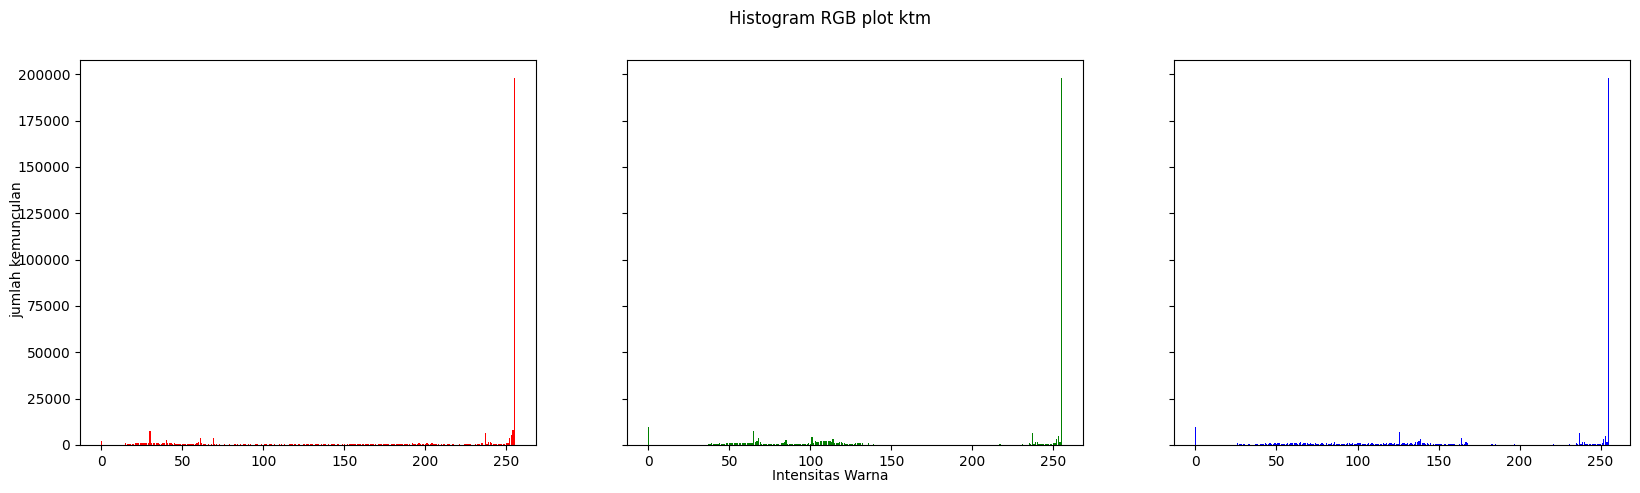

In [13]:
img = cv.imread('/content/drive/MyDrive/KTM.png')

img = cv.cvtColor(img,cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256


for y in range(0,height) :
  for x in range(0,width) :
    red[img[y][x][0]] += 1
    green[img[y][x][1]] += 1
    blue[img[y][x][2]] += 1

name = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=[20,5], sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot ktm')
fig.text(0.09, 0.5, 'jumlah kemunculan',va='center',rotation='vertical')
fig.text(0.5,0.04,'Intensitas Warna', ha = 'center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')

PERTANYAAN PRAKTIKUM E1

No 1

In [16]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

gray = cv.imread('/content/drive/MyDrive/lena.jpeg', cv.IMREAD_GRAYSCALE)

hist_manual = histogram_manual(gray)

hist_np, _ = np.histogram(gray.flatten(), bins=256, range=[0,256])

hist_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

print("Selisih Maks NumPy vs Manual:", np.max(np.abs(hist_np - hist_manual)))
print("Selisih Maks OpenCV vs Manual:", np.max(np.abs(hist_cv - hist_manual)))

Selisih Maks NumPy vs Manual: 0
Selisih Maks OpenCV vs Manual: 0


In [17]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

gray = cv.imread('/content/drive/MyDrive/KTM.png', cv.IMREAD_GRAYSCALE)

hist_manual = histogram_manual(gray)

hist_np, _ = np.histogram(gray.flatten(), bins=256, range=[0,256])

hist_cv = cv.calcHist([gray], [0], None, [256], [0, 256]).flatten().astype(np.int64)

print("Selisih Maks NumPy vs Manual:", np.max(np.abs(hist_np - hist_manual)))
print("Selisih Maks OpenCV vs Manual:", np.max(np.abs(hist_cv - hist_manual)))

Selisih Maks NumPy vs Manual: 0
Selisih Maks OpenCV vs Manual: 0


No 2

In [19]:
NIM = '244107020101'

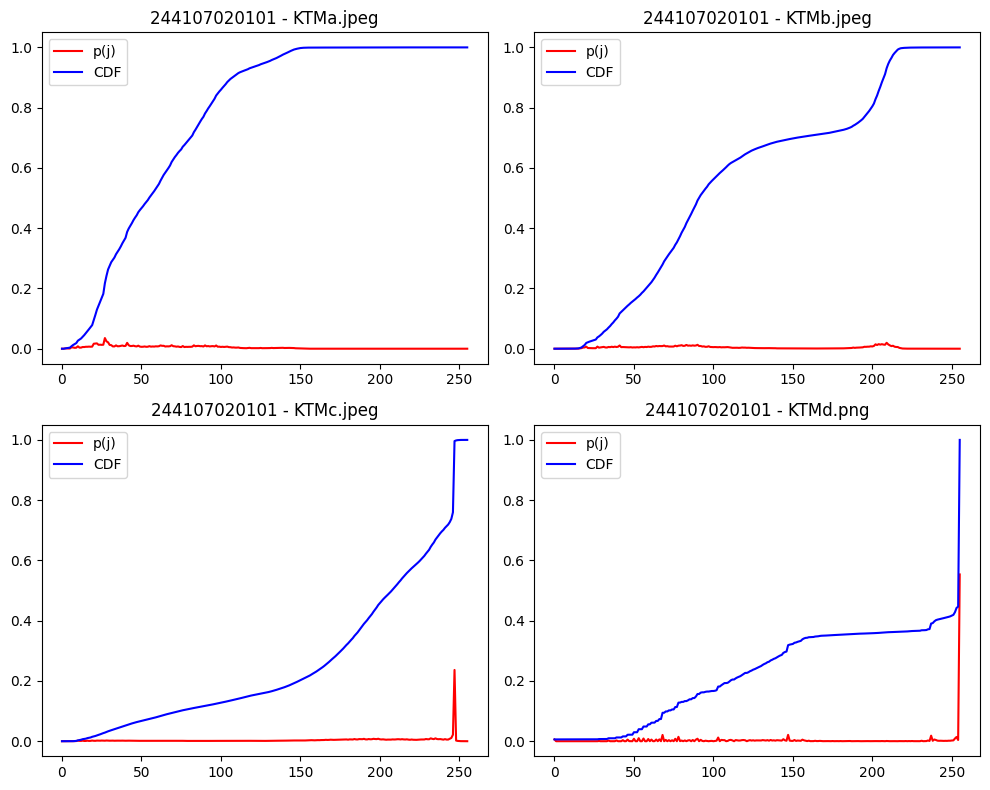

In [32]:
citra_ktm = ['KTMa.jpeg', 'KTMb.jpeg', 'KTMc.jpeg', 'KTMd.png']
plt.figure(figsize=(10, 8))

for i, nama_file in enumerate(citra_ktm, 1):
    img = cv.imread('/content/drive/MyDrive/' + nama_file, cv.IMREAD_GRAYSCALE)

    hist = histogram_manual(img)
    p = hist / img.size
    cdf = np.cumsum(p)

    plt.subplot(2, 2, i)
    plt.plot(p, color='red', label='p(j)')
    plt.plot(cdf, color='blue', label='CDF')
    plt.title(f'{NIM} - {nama_file}')
    plt.legend()

plt.tight_layout()
plt.show()

Analisis: Citra gelap (KTM1a) akan memiliki kurva CDF yang menanjak curam di sebelah kiri (intensitas rendah), sedangkan citra terang (KTM1d) akan landai di kiri dan menanjak tajam di sebelah kanan.